# Word2Vec on Novels Corpus

DS 5001 Text as Data

**Purpose:** We create word embeddings with novel data using word2vec and visualize results with tSNE.

# Set Up

In [1]:
import configparser
config = configparser.ConfigParser()
config.read("../../../env.ini")
data_home = config['DEFAULT']['data_home']
output_dir = config['DEFAULT']['output_dir']
local_lib = config['DEFAULT']['local_lib']

In [2]:
# Adjust this for a new corpus
data_prefix = 'novels'
table_dir =  f'{data_home}/{data_prefix}'
OHCO = ['book', 'chapter', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:4] # Paragraphs
SENT = OHCO[:5] # Sentences
BAG = PARA

In [3]:
# word2vec parameters
w2v_params = dict(
    window = 5,
    vector_size = 246,
    min_count = 50, # THIS LIMITS OUR VOCAB
    workers = 4
)

In [4]:
import pandas as pd
import numpy as np
from gensim.models import word2vec
from gensim.corpora import Dictionary
from sklearn.manifold import TSNE as tsne
import plotly_express as px

In [5]:
import gensim
gensim.__version__

'4.3.3'

# Import `TOKENS` and `VOCAB`

We import data from the TOKEN table of the novels corpus, excluding proper nouns.

In [6]:
TOKENS = pd.read_csv(f'{table_dir}/{data_prefix}-TOKENS.csv').set_index(OHCO)

In [7]:
TOKENS.head()

pos     term_str  term_id
book            chapter para_num sent_num token_num                           
secretadversary 1       0        1        0           DT          the    24127
                                          1          NNP        young    27354
                                          2          NNP  adventurers      399
                                          3          NNP          ltd    14406
                        1        0        0           JJ        tommy    24529

In [8]:
VOCAB = pd.read_csv(f'{table_dir}/{data_prefix}-VOCAB.csv').set_index('term_str')

In [9]:
VOCAB = VOCAB[~VOCAB.index.isna()] # There is NaN in the index for some reason

In [10]:
VOCAB.sample(5)

,term_id,n,p,port_stem,stop,df,idf,tfidf_sum,tfidf_mean,tfidf_max,pos_max
term_str,,,,,,,,,,,
addicted,287,4,2.665926e-06,addict,0,4,1.903090,7.612360,0.023789,1.903090,VBN
needing,15993,1,6.664814e-07,need,0,1,2.505150,2.505150,0.007829,2.505150,VBG
deplorable,6385,13,8.664258e-06,deplor,0,13,1.391207,18.085686,0.056518,1.391207,JJ
replacement,19931,10,6.664814e-06,replac,0,2,2.204120,22.041200,0.068879,11.020600,NN
vivify,26336,1,6.664814e-07,vivifi,0,1,2.505150,2.505150,0.007829,2.505150,VB


In [11]:
VOCAB['pos_max'] = TOKENS.groupby(['term_str','pos']).pos.count().unstack().idxmax(axis=1)

In [12]:
VOCAB

,term_id,n,p,port_stem,stop,df,idf,tfidf_sum,tfidf_mean,tfidf_max,pos_max
term_str,,,,,,,,,,,
a,0,28533,1.901671e-02,a,1,320,0.000000,0.000000,0.000000,0.000000,DT
aback,1,9,5.998332e-06,aback,0,9,1.550907,13.958167,0.043619,1.550907,NN
abaft,2,2,1.332963e-06,abaft,0,1,2.505150,5.010300,0.015657,5.010300,IN
abandon,3,44,2.932518e-05,abandon,0,28,1.057992,46.551646,0.145474,6.347952,VB
abandoned,4,68,4.532073e-05,abandon,0,43,0.871682,59.274344,0.185232,6.101771,VBN
...,...,...,...,...,...,...,...,...,...,...,...
à,27392,3,1.999444e-06,à,0,3,2.028029,6.084086,0.019013,2.028029,NNP
æt,27393,1,6.664814e-07,æt,0,1,2.505150,2.505150,0.007829,2.505150,NN
ætat,27394,1,6.664814e-07,ætat,0,1,2.505150,2.505150,0.007829,2.505150,VBD


# Convert to Gensim

We now create a Gensim-style corpus of docs, a list of lists of tokens.

In [13]:
# TOKENS

In [14]:
docs = TOKENS[~TOKENS.pos.str.match('NNPS?')].dropna(subset=['term_str'])\
    .groupby(BAG)\
    .term_str.apply(lambda  x:  x.tolist())\
    .reset_index()['term_str'].tolist()
docs = [doc for doc in docs if len(doc) > 1] # Lose single word docs

In [15]:
print(docs[:2])

[['to', 'she', 'is', 'always', 'woman'], ['i', 'have', 'seldom', 'heard', 'him', 'mention', 'her', 'under', 'any', 'other', 'name']]


In [16]:
vocab = Dictionary(docs)

# Generate word embeddings with Gensim's module

In [17]:
model = word2vec.Word2Vec(docs, **w2v_params)

In [18]:
model.wv.vectors

array([[-0.04452818, -0.29502437,  0.1714593 , ...,  0.00237275,
        -0.29508084, -1.316638  ],
       [ 0.36603767, -0.9374965 , -1.1328949 , ..., -0.5414639 ,
         0.30769274, -0.06694356],
       [-0.28025007, -0.19408502, -0.03370103, ..., -0.47254488,
         0.45166922, -0.60011375],
       ...,
       [ 0.09069922, -0.04735485, -0.06889595, ..., -0.11208795,
        -0.03414373,  0.11525939],
       [-0.08249667, -0.00552791,  0.08058899, ...,  0.03608384,
         0.21523666, -0.1165136 ],
       [ 0.05431635, -0.02556286,  0.00517448, ...,  0.134043  ,
         0.01770193, -0.01319083]], dtype=float32)

# Visualize with tSNE

## Convert model to data frame

In [19]:
def get_vector(row):
    w = row.name
    try:
        vec = model.wv[w]
    except KeyError as e:
        vec = None
    return vec

In [20]:
WV = pd.DataFrame(VOCAB.apply(get_vector, axis=1).dropna()).apply(lambda x: pd.Series(x[0]), axis=1)

In [21]:
WV

,0,1,2,3,4,5,6,7,8,9,...,236,237,238,239,240,241,242,243,244,245
term_str,,,,,,,,,,,,,,,,,,,,,
a,-0.566392,-0.322921,0.196464,0.873904,-0.499756,-0.039135,-0.334265,-0.486096,-0.276281,0.434750,...,-0.207369,-0.077271,0.265323,0.403782,-0.333269,0.066970,-0.466043,0.042456,-0.429178,-1.084360
abandoned,-0.001547,-0.037369,0.159783,0.026611,-0.128456,0.007784,-0.112420,-0.131964,-0.107707,-0.043245,...,0.040991,0.106923,-0.041731,-0.197981,0.220048,0.068175,0.118844,-0.025836,0.054749,0.016265
abbess,-0.026507,-0.062549,0.059090,0.029888,-0.043611,-0.078121,-0.170172,-0.167600,0.065361,0.004020,...,-0.075226,0.082496,-0.038373,0.061400,-0.017228,-0.030946,0.063789,0.084817,0.125135,0.060018
able,0.313634,-0.861455,0.093285,-0.179104,0.155603,-0.308867,-0.387651,-0.467256,-0.259380,0.102710,...,-0.242009,0.706567,-0.121122,0.143118,-0.016571,0.037443,0.036185,0.216194,0.055234,0.418300
about,-0.290189,-0.188635,-0.241417,0.006739,0.236596,-0.169880,0.152508,-0.630014,-0.296671,0.329103,...,0.347553,0.113612,-0.118368,-0.208952,-0.030527,-0.469581,-0.163638,0.074897,-0.035791,0.921585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
youre,0.075181,-0.016325,-0.225774,-0.003227,-0.015139,-0.110016,-0.422974,0.043122,-0.203864,0.040772,...,0.040525,0.219198,-0.211179,0.235865,-0.368146,-0.254633,-0.118250,0.282772,-0.140981,0.313775
yours,-0.024670,-0.264667,0.129983,-0.055082,0.098342,0.083039,-0.343012,-0.268612,0.041687,0.137012,...,-0.144484,0.059717,-0.025872,0.236517,-0.175744,-0.006000,-0.152873,0.049771,-0.397410,-0.020770
yourself,0.065041,-0.287972,-0.269787,-0.149236,0.603930,0.260299,-0.401422,0.010375,-0.108689,-0.140166,...,-0.250847,0.026630,-0.107250,0.570975,-0.206720,0.154984,-0.163936,0.105008,-0.945728,0.066904


## Use ScikitLearn's TSNE library

In [22]:
tsne_engine = tsne(perplexity=40, n_components=2, init='pca', n_iter=2500, random_state=23)

In [23]:
tsne_model = tsne_engine.fit_transform(WV.to_numpy())

In [24]:
TSNE = pd.DataFrame(tsne_model, columns=['x','y'], index=WV.index)

In [25]:
TSNE

,x,y
term_str,,
a,-5.834268,33.405956
abandoned,-10.164809,-25.432049
abbess,-10.818237,-6.528579
able,39.973446,16.949026
about,0.705252,25.310450
...,...,...
youre,35.375580,3.075963
yours,34.545338,-3.089371
yourself,44.235531,6.128057


## Plot the coordinates

In [26]:
VOCAB['dfidf'] = VOCAB.df * VOCAB.idf

In [27]:
X = TSNE.join(VOCAB, how='left')

In [28]:
X.head()

,x,y,term_id,n,p,port_stem,stop,df,idf,tfidf_sum,tfidf_mean,tfidf_max,pos_max,dfidf
term_str,,,,,,,,,,,,,,
a,-5.834268,33.405956,0,28533,0.019017,a,1,320,0.000000,0.000000,0.000000,0.000000,DT,0.000000
abandoned,-10.164809,-25.432049,4,68,0.000045,abandon,0,43,0.871682,59.274344,0.185232,6.101771,VBN,37.482305
abbess,-10.818237,-6.528579,14,69,0.000046,abbess,0,12,1.425969,98.391843,0.307475,31.371312,NN,17.111625
able,39.973446,16.949026,50,315,0.000210,abl,0,173,0.267104,84.137721,0.262930,1.602623,JJ,46.208970
about,0.705252,25.310450,71,2000,0.001333,about,1,295,0.035328,70.655925,0.220800,1.377791,IN,10.421749


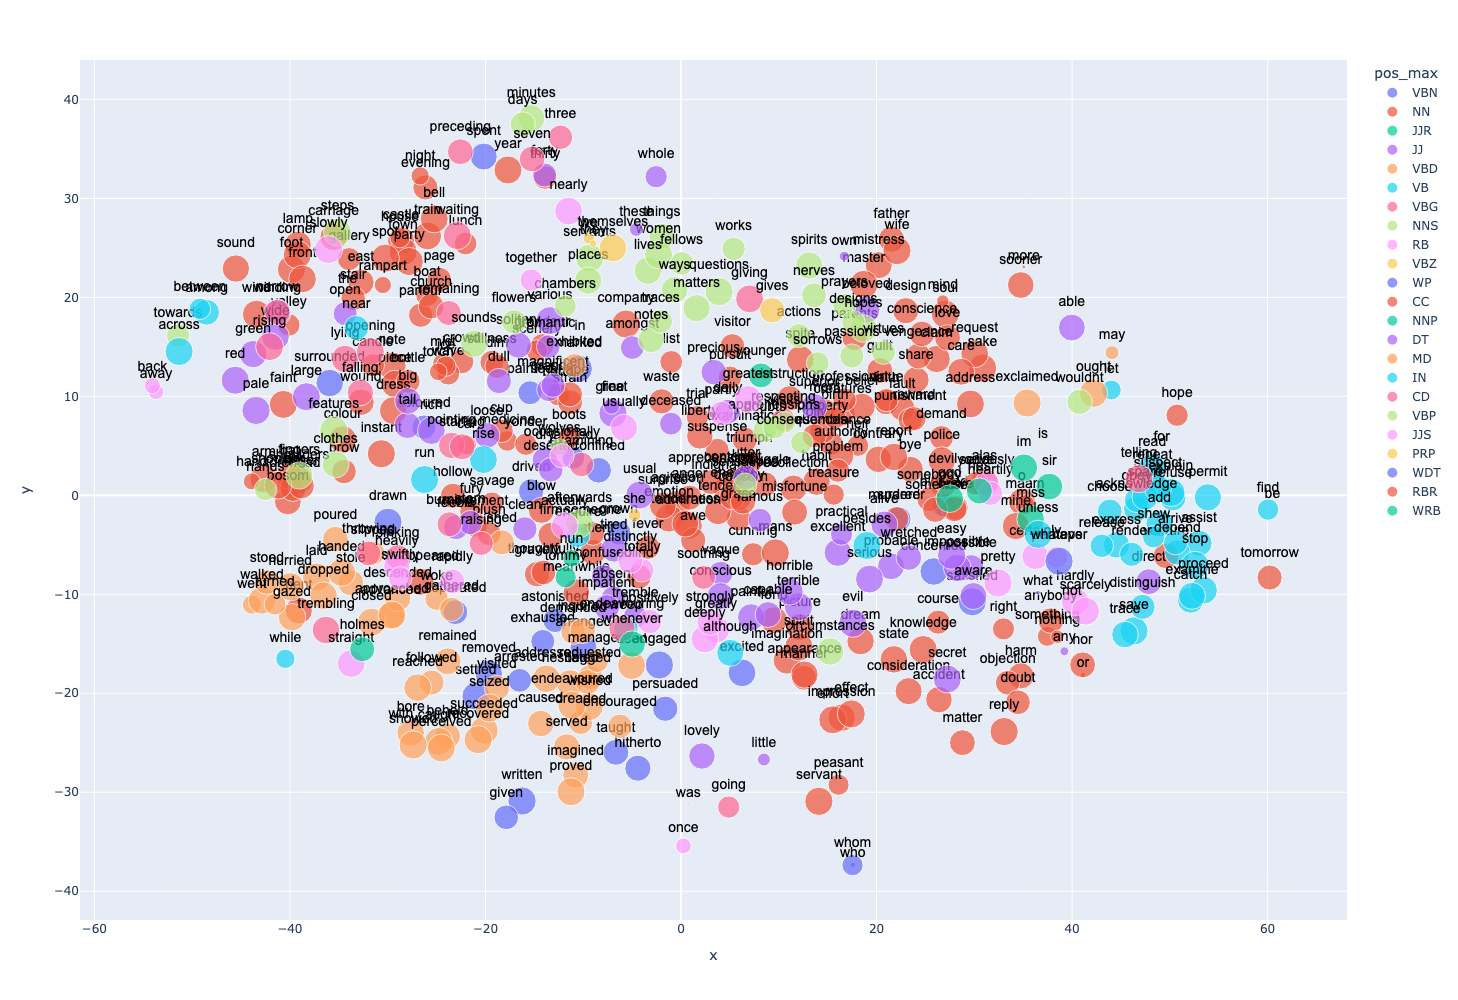

In [59]:
px.scatter(X.reset_index().sample(500), 'x', 'y', 
           text='term_str', 
           color='pos_max', 
           hover_name='term_str',          
           size='dfidf',
           height=1000, width=1200).update_traces(
                mode='markers+text', 
                textfont=dict(color='black', size=14, family='Arial'),
                textposition='top center')

# Semantic Algebra

## Analogies

$A : B :: C : D? \rightarrow B - A + C = D$


In [30]:
def complete_analogy(A, B, C, n=2):
    try:
        cols = ['term', 'sim']
        return pd.DataFrame(model.wv.most_similar(positive=[B, C], negative=[A])[0:n], columns=cols)
    except KeyError as e:
        print('Error:', e)
        return None
    
def get_most_similar(positive, negative=None):
    return pd.DataFrame(model.wv.most_similar(positive, negative), columns=['term', 'sim'])

In [31]:
complete_analogy('man', 'boy', 'woman', 3)

,term,sim
0,girl,0.768608
1,peasant,0.728882
2,lady,0.711549


In [32]:
complete_analogy('girl', 'daughter', 'boy', 3)

,term,sim
0,wife,0.787292
1,son,0.787080
2,mistress,0.774548


In [33]:
complete_analogy('girl', 'sister', 'boy', 3)

,term,sim
0,son,0.822300
1,mistress,0.802481
2,wife,0.798501


In [34]:
complete_analogy('man', 'gentleman', 'woman', 5)

,term,sim
0,girl,0.824099
1,peasant,0.771658
2,lady,0.767006
3,fellow,0.718756
4,young,0.676703


In [35]:
complete_analogy('man', 'woman', 'gentleman', 5)

,term,sim
0,girl,0.824099
1,peasant,0.771658
2,lady,0.767006
3,fellow,0.718756
4,young,0.676703


In [36]:
complete_analogy('woman', 'man', 'lady', 5)

,term,sim
0,gentleman,0.736253
1,girl,0.714408
2,boy,0.680336
3,fellow,0.671380
4,friend,0.657295


In [37]:
complete_analogy('day', 'night', 'sun', 5)

,term,sim
0,rain,0.834916
1,snow,0.805561
2,breeze,0.798214
3,wind,0.797175
4,clouds,0.795140


In [38]:
complete_analogy('woman','answered','man', 5)

,term,sim
0,added,0.687711
1,says,0.664958
2,replied,0.658510
3,remarked,0.656786
4,cried,0.646623


In [39]:
complete_analogy('man','replied','woman', 5)

,term,sim
0,said,0.719234
1,answered,0.694195
2,dear,0.690997
3,oh,0.678060
4,thinks,0.664345


In [40]:
complete_analogy('wife', 'appeared', 'husband', 5)

,term,sim
0,seemed,0.819141
1,sought,0.573180
2,remains,0.562681
3,considered,0.556718
4,perceived,0.554766


In [41]:
complete_analogy('husband', 'appeared', 'wife', 5)

,term,sim
0,seemed,0.676531
1,described,0.647785
2,perceived,0.636323
3,distinguished,0.633517
4,observed,0.615715


In [42]:
complete_analogy('man', 'father', 'woman', 5)

,term,sim
0,mother,0.853830
1,aunt,0.832206
2,husband,0.826239
3,niece,0.784293
4,daughter,0.783545


In [43]:
complete_analogy('man', 'husband', 'woman', 5)

,term,sim
0,mother,0.831125
1,aunt,0.801266
2,father,0.785376
3,niece,0.780882
4,mistress,0.762488


In [44]:
complete_analogy('man', 'castle', 'woman', 5)

,term,sim
0,house,0.726466
1,convent,0.710662
2,chateau,0.658154
3,neighbourhood,0.644014
4,country,0.643581


In [45]:
complete_analogy('woman', 'home', 'man', 5)

,term,sim
0,ready,0.661511
1,off,0.641604
2,rest,0.639122
3,station,0.632336
4,dinner,0.630289


## Similarites

In [46]:
get_most_similar('joy')

,term,sim
0,admiration,0.906951
1,tenderness,0.897059
2,grief,0.883257
3,terror,0.857968
4,horror,0.850287
5,delight,0.842064
6,sorrow,0.834446
7,terrors,0.834167
8,satisfaction,0.833673
9,indignation,0.832627


In [47]:
get_most_similar('man')

,term,sim
0,woman,0.848521
1,gentleman,0.833755
2,girl,0.767381
3,fellow,0.717778
4,peasant,0.715092
5,stranger,0.697611
6,person,0.671566
7,creature,0.671383
8,lady,0.653061
9,servant,0.636068


In [48]:
get_most_similar(positive=['man'], negative=['woman'])

,term,sim
0,he,0.326918
1,them,0.313058
2,lie,0.310371
3,his,0.308016
4,off,0.295386
5,key,0.287352
6,right,0.283483
7,case,0.280794
8,way,0.280665
9,him,0.272311


In [49]:
get_most_similar(positive='woman')

,term,sim
0,girl,0.863714
1,gentleman,0.851861
2,man,0.848521
3,peasant,0.802143
4,fellow,0.764371
5,stranger,0.751199
6,lady,0.740729
7,creature,0.734442
8,youth,0.672448
9,child,0.668214


In [50]:
get_most_similar(positive=['woman'], negative=['man'])

,term,sim
0,particularly,0.406309
1,sweet,0.391981
2,beloved,0.388378
3,painful,0.384021
4,late,0.378639
5,sad,0.367065
6,greatly,0.365298
7,sensible,0.363907
8,spirits,0.363789
9,young,0.363447


In [51]:
get_most_similar(['man','woman'],['boy','girl'])

,term,sim
0,nor,0.475223
1,human,0.439454
2,even,0.428046
3,produce,0.413480
4,importance,0.410052
5,or,0.396342
6,greater,0.394546
7,self,0.393898
8,person,0.388133
9,degree,0.387261


# View with HAC

In [52]:
import sys
sys.path.append(local_lib)
from hac2 import HAC

In [53]:
WV2 = WV.join(VOCAB.pos_max)
WV2 = WV2[~WV2.pos_max.str.match(r"NNPS?")].iloc[:, :-1]

<Figure size 640x480 with 0 Axes>

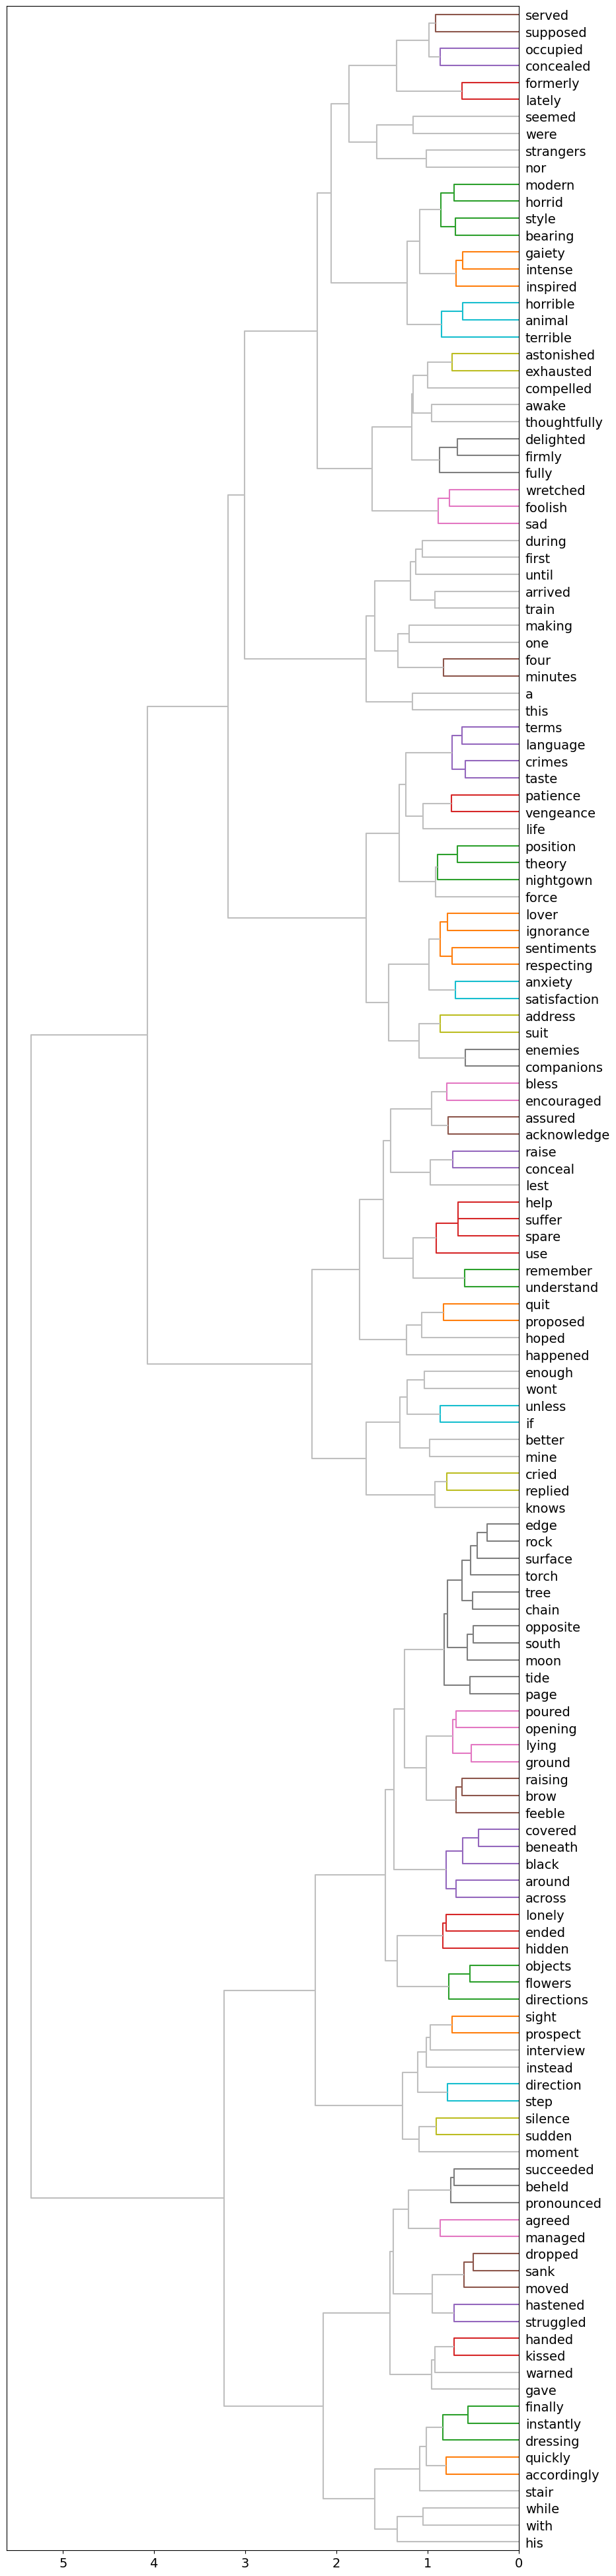

In [54]:
HAC(WV2.sample(150)).plot()

# Save

In [55]:
# W2V = pd.DataFrame(model.wv.vectors_norm, index=model.wv.vocab.keys())
# WV.to_csv('{}/{}-W2V.csv'.format(data_out, data_prefix))
# pd.Series(DOCS).to_csv('{}/{}-GENSIM_DOCS.csv'.format(data_out, data_prefix), index=False, header=False)